# SLDS Step 2: Model Training

Goal: Train a Switching Linear Dynamical System (SLDS) model using `pyslds` on continuous features.

Mathematical Model:

$$
z_t \sim \text{Discrete}(z_{t-1}, \pi) \quad \text{(mode switching)}
$$

$$
x_t = A_{z_t} x_{t-1} + b_{z_t} + w_t, \quad w_t \sim \mathcal{N}(0, Q_{z_t}) \quad \text{(continuous dynamics)}
$$

$$
y_t = C x_t + v_t, \quad v_t \sim \mathcal{N}(0, R) \quad (C=I \text{ here})
$$

Where:
- $z_t \in \{0, ..., K-1\}$: discrete mode (phase-only in current prep)
- $x_t \in \mathbb{R}^4$: latent state `[vx, vy, h_dot, altitude]` (standardized)
- $y_t \in \mathbb{R}^4$: observations (same as latent state, since C=I)
- $A_k$: dynamics matrix for mode $k$
- $Q_k$: process noise covariance for mode $k$

Notes:
- Modes (phases) are provided by preparation; Gibbs will still refine transitions/parameters.
- Identity emissions keep training stable and fast with standardized features.

## 1. Setup and Load Data

In [19]:
# Python: preferred in a notebook
import os, subprocess
print("kernel hostname:", os.uname().nodename)
print("HOSTNAME env:", os.environ.get("HOSTNAME"))
print("SLURM_NODELIST:", os.environ.get("SLURM_NODELIST"))
print("SLURM_JOB_NODELIST:", os.environ.get("SLURM_JOB_NODELIST"))
# expand nodelist to concrete hostnames (if scontrol available)
if os.environ.get("SLURM_NODELIST"):
    print("Expanded nodes:",
          subprocess.check_output(["scontrol","show","hostnames", os.environ["SLURM_NODELIST"]]).decode().strip())

kernel hostname: srv-lab-t-251
HOSTNAME env: srv-lab-t-252
SLURM_NODELIST: srv-lab-t-251
SLURM_JOB_NODELIST: srv-lab-t-251
Expanded nodes: srv-lab-t-251


In [20]:
try:
    import pylds, pyhsmm, pyslds
    from pylds import lds_messages  # ensures C extension is loaded
    from pyhsmm.internals import hmm_messages_interface  # ensures C extension
    from pyslds.models import DefaultSLDS
    print("Environment OK: compiled extensions present.")
except Exception as e:
    raise RuntimeError(f"Env check failed: {e}")

Environment OK: compiled extensions present.


In [21]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Prefer local VT_2 sources to avoid version mismatches
import sys as _sys, importlib as _importlib
_local_libs = [
    '/home/fusg/VT_2/pybasicbayes-master',
    '/home/fusg/VT_2/pyhsmm-master',
    '/home/fusg/VT_2/pylds-master',
    '/home/fusg/VT_2/pyslds-master',
]
for _p in reversed(_local_libs):  # ensure pyslds sees compatible deps first
    if _p not in _sys.path:
        _sys.path.insert(0, _p)

# Proactively clear potentially conflicting installed modules
for _m in ['pyslds', 'pybasicbayes', 'pyhsmm', 'pylds']:
    if _m in _sys.modules:
        del _sys.modules[_m]

# Import local pyslds (which will import local deps via sys.path precedence)
import pyslds
# Ensure pyhsmm models submodule is loaded and attached
import pyhsmm
import pyhsmm.models as _hsmm_models
pyhsmm.models = _hsmm_models
from pyslds.models import DefaultSLDS

# Helpful provenance prints
print(f"pyslds imported from: {pyslds.__file__}")
try:
    import pybasicbayes as _pbb
    print(f"pybasicbayes: {_pbb.__version__ if hasattr(_pbb,'__version__') else 'unknown'} @ {_pbb.__file__}")
except Exception as _e:
    print("pybasicbayes import check failed:", repr(_e))
try:
    import pyhsmm as _pyhsmm
    print(f"pyhsmm @ {_pyhsmm.__file__}")
except Exception:
    pass

# Plotting style
plt.rcParams.update({
    'font.family': 'cmr10',
    'font.size': 13,
    'figure.dpi': 150
})


pyslds imported from: /home/fusg/VT_2/pyslds-master/pyslds/__init__.py
pybasicbayes: unknown @ /home/fusg/VT_2/pybasicbayes-master/pybasicbayes/__init__.py
pyhsmm @ /home/fusg/VT_2/pyhsmm-master/pyhsmm/__init__.py


In [22]:
# Load prepared SLDS data
pkl_path = "/store/fusg/VT2/slds/slds_data_prepared_v2.pkl"
try:
    with open(pkl_path, 'rb') as f:
        slds_data = pickle.load(f)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Missing data file: {pkl_path}.\n"
        f"Please run SLDS_01_data_preparation.ipynb to generate it, or update 'pkl_path'."
    )

observations = slds_data['observations']
mode_sequences = slds_data.get('mode_sequences')
flight_ids = slds_data.get('flight_ids')
metadata = slds_data['metadata']

K_modes = int(metadata['K_modes'])
D_obs = int(metadata['D_obs'])
D_latent = int(metadata['D_latent'])
feature_names = metadata.get('feature_names', [])
N_phases = int(metadata.get('N_phases'))
N_type_clusters = int(metadata.get('N_typecode_clusters'))
phase_mapping = metadata.get('phase_mapping', {})

# Sanity checks and helpful prints
obs_dim_actual = int(observations[0].shape[1]) if observations else D_obs
if D_obs != obs_dim_actual:
    print(f"⚠ D_obs in metadata ({D_obs}) != observed dim ({obs_dim_actual}). Using observed dim.")
    D_obs = obs_dim_actual
    D_latent = obs_dim_actual

expected_K = int(N_type_clusters) * int(N_phases)
if K_modes != expected_K:
    print(f"⚠ K mismatch: metadata K_modes={K_modes}, but N_type_clusters×N_phases={expected_K}. Using metadata K.")

total_T = sum(len(y) for y in observations)
print("Loaded SLDS data:")
print(f"  - {len(observations)} flights")
print(f"  - K = {K_modes} modes ({N_type_clusters} type clusters × {N_phases} phases)")
print(f"  - D_obs = {D_obs}, D_latent = {D_latent}  (features: {', '.join(feature_names)})")
print(f"  - Total timesteps: {total_T:,}")
print(f"  - Phases: {list(phase_mapping.keys())}")

Loaded SLDS data:
  - 141661 flights
  - K = 5 modes (1 type clusters × 5 phases)
  - D_obs = 4, D_latent = 4  (features: vx, vy, vertical_rate, altitude)
  - Total timesteps: 98,682,075
  - Phases: ['CLIMB', 'CRUISE', 'DESCENT', 'LEVEL', 'NA']


## Initialize SLDS Model

Model Choice: `pyslds.models.DefaultSLDS`

Key Parameters:
- K: Number of discrete modes = N_typecode_clusters × N_phases (from preparation)
- D_obs: Observation dimension = 4 (vx, vy, h_dot, altitude)
- D_latent: Latent state dimension = 4 (identity observation model)
- dynamics_noise_scale: Prior on process noise Q_k (higher = more flexible dynamics)
- emission_noise_scale: Prior on observation noise R_k (lower = trust observations more)

Design Decision: We use identity observation model (C = I, d = 0) because our "latent state" equals what we observe.

$y_t = x_t + v_t, \quad v_t \sim \mathcal{N}(0, \sigma^2 I)$

We’ll use light regularization to keep dynamics stable across modes.

In [23]:
# Compatibility patches for pybasicbayes Regression under NumPy >= 2
import numpy as np
import sys as _sys
import os
import pickle

# Guard: ensure core metadata variables exist even if previous cells weren't run
if 'metadata' not in globals() or 'observations' not in globals():
    pkl_path = os.environ.get('SLDS_DATA_PKL', "/store/fusg/VT2/slds/slds_data_prepared.pkl")
    with open(pkl_path, 'rb') as _f:
        _slds_data = pickle.load(_f)
    observations = _slds_data['observations']
    metadata = _slds_data['metadata']

# Derive dims robustly
D_obs = int(metadata.get('D_obs', observations[0].shape[1]))
D_latent = int(metadata.get('D_latent', D_obs))
feature_names = metadata.get('feature_names', ['vx','vy','vertical_rate','altitude'][:D_obs])
K_modes = int(metadata.get('K_modes', max(1, int(metadata.get('N_typecode_clusters', 1)) * int(metadata.get('N_phases', 1)))) )

# Force local pybasicbayes (avoid site-package SciPy misc dependency)
_local_pbb = '/home/fusg/VT_2/pybasicbayes-master'
if _local_pbb not in _sys.path:
    _sys.path.insert(0, _local_pbb)
if 'pybasicbayes' in _sys.modules:
    del _sys.modules['pybasicbayes']

from pybasicbayes.distributions.regression import Regression as _Regression
from pybasicbayes.util.general import objarray as _objarray
from pybasicbayes.util.general import inv_psd as _inv_psd

def _reg_empty_statistics(self):
    D_in, D_out = self.D_in, self.D_out
    return np.array([
        np.zeros((D_out, D_out)),
        np.zeros((D_out, D_in)),
        np.zeros((D_in, D_in)),
        0
], dtype=object)

def _reg_standard_to_natural(nu, S, M, K):
    Kinv = _inv_psd(K)
    A = S + M.dot(Kinv).dot(M.T)
    B = M.dot(Kinv)
    C = Kinv
    d = nu
    return _objarray([A, B, C, d])

# Apply patches
_Regression._empty_statistics = _reg_empty_statistics
_Regression._standard_to_natural = staticmethod(_reg_standard_to_natural)
print("Applied Regression patches: _empty_statistics -> dtype=object, _standard_to_natural -> objarray")

# Initialize SLDS model with LIGHT regularization
identity_C = np.eye(D_obs)

from pyslds.models import DefaultSLDS

# Initialize with identity dynamics and moderate process noise
a_proc = 0.5  # base process noise scale
As_init = [np.eye(D_latent) for _ in range(K_modes)]
Q_init = [a_proc * np.eye(D_latent) for _ in range(K_modes)]

# Create model 
model = DefaultSLDS(
    K=K_modes,
    D_obs=D_obs,
    D_latent=D_latent,
    As=As_init,
    sigma_statess=Q_init,
    Cs=identity_C,
    sigma_obss=0.05 * np.eye(D_obs),  # slightly higher obs noise; less over-trust
    alpha=3.0
)

# Set generic priors (Matrix-Normal-Inverse-Wishart)
print("\nSetting generic dynamics priors for stability...")
M_prior = 0.95 * np.eye(D_latent)  # slight damping on all states
S_0 = np.eye(D_latent)
K_0 = 1.0 * np.eye(D_latent)
nu_0 = D_latent + 5

for k in range(K_modes):
    dyn = model.dynamics_distns[k]
    dyn.nu_0 = nu_0
    dyn.S_0 = S_0.copy()
    dyn.M = M_prior.copy()
    dyn.K = K_0.copy()
    dyn.natural_hypparam = dyn._standard_to_natural(dyn.nu_0, dyn.S_0, dyn.M, dyn.K)

print(f"✓ Applied generic priors: diag(M_prior)={np.diag(M_prior)} nu_0={nu_0}")

Applied Regression patches: _empty_statistics -> dtype=object, _standard_to_natural -> objarray

Setting generic dynamics priors for stability...
✓ Applied generic priors: diag(M_prior)=[0.95 0.95 0.95 0.95] nu_0=9


## Add Training Data

In [24]:
# Select set for training
N_TRAIN = 1000

print(f"Adding {N_TRAIN} flights to SLDS model...")
for i, y in enumerate(tqdm(observations[:N_TRAIN], desc="Adding data")):
    z = None
    if mode_sequences is not None and i < len(mode_sequences):
        z = mode_sequences[i]
    if z is not None and len(z) == len(y):
        # Seed with supervised modes for faster convergence
        model.add_data(y, stateseq=np.asarray(z, dtype=np.int32), initialize_from_prior=False)
    else:
        model.add_data(y)

print(f"\nAdded {len(model.states_list)} flight sequences")
print(f"  Total timesteps used: {sum(len(y) for y in observations[:N_TRAIN]):,}")
print(f"  Average timesteps per flight: {sum(len(y) for y in observations[:N_TRAIN]) / N_TRAIN:.0f}")

Adding 1000 flights to SLDS model...


Adding data: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:38<00:00, 26.16it/s]


Added 1000 flight sequences
  Total timesteps used: 850,051
  Average timesteps per flight: 850


## Train SLDS via Gibbs Sampling

**Training Algorithm**: Gibbs sampling alternates between:
1. **Sample latent states** $x_{1:T}$ given current parameters $\{A_k, Q_k\}$ and modes $z_{1:T}$
2. **Sample modes** $z_{1:T}$ given latent states $x_{1:T}$ and transition probabilities
3. **Resample parameters** $\{A_k, Q_k, b_k\}$ given latent states and modes

In [25]:
# Patch pybasicbayes Regression._get_statistics to return dtype=object arrays under NumPy >= 2
import numpy as np
from pybasicbayes.distributions.regression import Regression as _Regression

def _reg_get_statistics(self, data):
    assert isinstance(data, (list, tuple, np.ndarray))
    if isinstance(data, list):
        return sum((self._get_statistics(d) for d in data), self._empty_statistics())
    elif isinstance(data, tuple):
        x, y = data
        x = np.asarray(x)
        y = np.asarray(y)
        n = x.shape[0] if x.ndim == 2 else y.shape[0]
        # Ensure 2D with shape (D, T) for inner products
        y2 = y.T if y.ndim == 2 else y[:, None].T
        x2 = x.T if x.ndim == 2 else x[:, None].T
        yyT = y2 @ y2.T
        yxT = y2 @ x2.T
        xxT = x2 @ x2.T
        return np.array([yyT, yxT, xxT, n], dtype=object)
    else:
        # data passed in like np.hstack((x, y))
        data = data[~np.isnan(data).any(1)]
        y = data[:, :self.D_out].T
        x = data[:, self.D_out:].T
        n = x.shape[1]
        yyT = y @ y.T
        yxT = y @ x.T
        xxT = x @ x.T
        return np.array([yyT, yxT, xxT, n], dtype=object)

_Regression._get_statistics = _reg_get_statistics
print("Patched Regression._get_statistics to use dtype=object")

# Training hyperparameters  
N_ITER = 125
LOG_EVERY = 10

# Track log-likelihood for convergence diagnosis
log_likelihoods = []

print(f"\nStarting Gibbs sampling for {N_ITER} iterations with {N_TRAIN} flights ...")
for itr in tqdm(range(N_ITER), desc="Gibbs iterations"):
    # One Gibbs sweep: resample states, modes, and parameters
    model.resample_model()
    
    # Compute log-likelihood (expensive, so do sparingly)
    if itr % LOG_EVERY == 0 or itr == N_ITER - 1:
        ll = model.log_likelihood()
        log_likelihoods.append(ll)
        print(f"Iteration {itr:4d}: Log-likelihood = {ll:.2f}")

print("\n✓ Training complete!")

Patched Regression._get_statistics to use dtype=object

Starting Gibbs sampling for 125 iterations with 1000 flights ...


Gibbs iterations:   1%|█                                                                                                                                           | 1/125 [00:09<19:35,  9.48s/it]

Iteration    0: Log-likelihood = 163621.61


Gibbs iterations:   9%|████████████▏                                                                                                                              | 11/125 [01:42<17:34,  9.25s/it]

Iteration   10: Log-likelihood = 16183835.85


...

Iteration  110: Log-likelihood = 30378637.65


Gibbs iterations:  97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌    | 121/125 [18:42<00:36,  9.06s/it]

Iteration  120: Log-likelihood = 30379864.84


Gibbs iterations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [19:19<00:00,  9.27s/it]

Iteration  124: Log-likelihood = 30378884.43

✓ Training complete!


## Convergence Diagnostics

**Check**: Log-likelihood should increase and plateau.

**If not converged**: 
- Increase `N_ITER`
- Adjust priors (`dynamics_noise_scale`, `emission_noise_scale`)
- Check for numerical issues (NaNs, underflow)

/tmp/ipykernel_2935204/3850721002.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(10, 5))


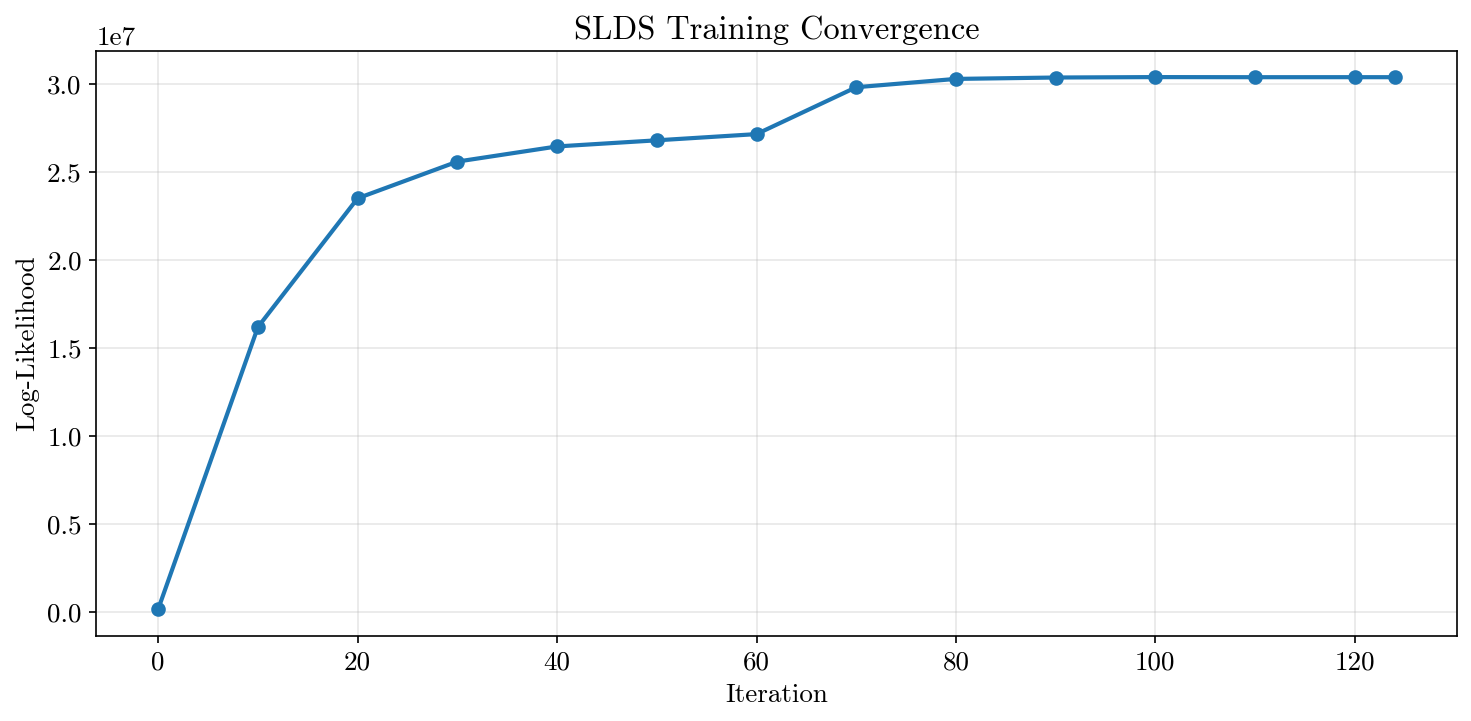


Convergence Summary:
  Initial LL: 163621.61
  Final LL:   30378884.43
  Improvement: 30215262.82


In [26]:
# Plot log-likelihood convergence
fig, ax = plt.subplots(figsize=(10, 5))
iterations = np.arange(0, N_ITER, LOG_EVERY).tolist() + [N_ITER - 1]
ax.plot(iterations[:len(log_likelihoods)], log_likelihoods, 'o-', linewidth=2, markersize=6)
ax.set_xlabel('Iteration')
ax.set_ylabel('Log-Likelihood')
ax.set_title('SLDS Training Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nConvergence Summary:")
print(f"  Initial LL: {log_likelihoods[0]:.2f}")
print(f"  Final LL:   {log_likelihoods[-1]:.2f}")
print(f"  Improvement: {log_likelihoods[-1] - log_likelihoods[0]:.2f}")

## Inspect Learned Parameters

**What did SLDS learn?**

For each mode $k$, we have:
- **Dynamics matrix** $A_k$ : How current state affects next state
- **Bias** $b_k$ (4×1): Constant offset (e.g., drag, thrust)
- **Process noise** $Q_k$ : Uncertainty/variability in dynamics

**Physical Interpretation** (example for mode k):

$$
\begin{bmatrix} v_{t+1} \\ \dot{v}_{t+1} \\ \dot{\psi}_{t+1} \\ \dot{h}_{t+1} \end{bmatrix} = 
A_k \begin{bmatrix} v_t \\ \dot{v}_t \\ \dot{\psi}_t \\ \dot{h}_t \end{bmatrix} + b_k + w_t
$$

**Expected patterns**:
- $A_k[0, 0] \approx 1$: Groundspeed persists
- $A_k[0, 1] > 0$: Acceleration increases groundspeed
- $A_k[2, 2] < 1$: Turn rate decays (damping)
- $A_k[3, 3] < 1$: Vertical rate decays

In [27]:
# Extract learned dynamics for first few modes
print("\nLearned Dynamics Matrices (sample modes):\n")
print("Mode structure: (typecode_cluster, phase)\n")

N_phases = metadata['N_phases']
phase_names = list(metadata.get('phase_mapping', {}).keys())

for k in range(min(5, K_modes)):  # Show first 5 modes
    # Decode mode index (typecode_cluster × phase)
    typecode_cluster = k // N_phases
    phase_idx = k % N_phases
    phase_name = phase_names[phase_idx] if phase_names and phase_idx < len(phase_names) else str(phase_idx)

    # Get dynamics for this mode
    A_k = model.dynamics_distns[k].A
    b_k = getattr(model.dynamics_distns[k], 'b', None)
    Q_k = model.dynamics_distns[k].sigma

    print(f"Mode {k} (cluster={typecode_cluster}, phase={phase_name}):")
    print(f"  A matrix ({A_k.shape[0]}×{A_k.shape[1]}):")
    print(f"    {A_k}")
    if b_k is not None:
        print(f"  b vector: {b_k}")
    print(f"  Q noise diag: {np.diag(Q_k)}")
    print()


Learned Dynamics Matrices (sample modes):

Mode structure: (typecode_cluster, phase)

Mode 0 (cluster=0, phase=CLIMB):
  A matrix (4×4):
    [[-3.17968473e-01 -1.98570058e-01 -5.57953793e-03 -7.12013082e-02]
 [-2.36665285e-02 -1.87493815e-01  7.79331301e-02  4.77491514e-02]
 [-8.26893459e-02  1.30230515e-01  4.48301756e-01  1.42212833e-02]
 [ 9.93437282e-03 -5.62873424e-05  9.25831707e-04  9.97838417e-01]]
  Q noise diag: [1.01777003e+00 1.20482115e+00 5.71712615e+00 4.98159998e-03]

Mode 1 (cluster=0, phase=CRUISE):
  A matrix (4×4):
    [[ 1.00002512e+00 -9.36231961e-07 -1.11248685e-05  1.27984179e-05]
 [-1.42858450e-05  1.00000682e+00 -3.03843762e-05  5.60892064e-05]
 [ 6.20218705e-04  2.86001753e-04  9.95373156e-01 -8.81615418e-05]
 [-4.42243552e-05 -5.16237942e-05  2.30916767e-03  9.99890969e-01]]
  Q noise diag: [1.13584369e-05 1.05890752e-05 1.72875258e-03 9.07910099e-06]

Mode 2 (cluster=0, phase=DESCENT):
  A matrix (4×4):
    [[ 9.98561504e-01 -3.86972380e-04  6.75814506e-04

## Visualize Dynamics for Key Modes

Heatmap of $A_k$ matrices: Shows coupling between state variables.

Interpretation guide:
- Diagonal elements: Persistence (close to 1 = state persists)
- Off-diagonal: Cross-coupling (e.g., $A[0,1]$ = how acceleration affects groundspeed)

Cross-reference to DBN: In the DBN, CPTs captured discrete dependencies. Here, $A_k$ encodes linear-Gaussian coupling on the continuous 5D state (including altitude).

Note: With altitude included, we expect meaningful couplings with vertical rate and altitude rows/columns.

/tmp/ipykernel_2935204/3862577092.py:4: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = plt.subplots(1, len(modes_to_plot), figsize=(18, 4))
/tmp/ipykernel_2935204/3862577092.py:45: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.15, label='Matrix Value')
/tmp/ipykernel_2935204/3862577092.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2935204/3862577092.py:47: UserWarning: Glyph 775 (\N{COMBINING DOT ABOVE}) missing from font(s) cmr10.
  plt.tight_layout()
/tmp/ipykernel_2935204/3862577092.py:47: UserWarning: Glyph 968 (\N{GREEK SMALL LETTER PSI}) missing from font(s) cmr10.
  plt.tight_layout()
/tmp/ipykernel_2935204/3862577092.py:47: UserWarning: Glyph 7715 (\N{LATIN SMALL LETTER H

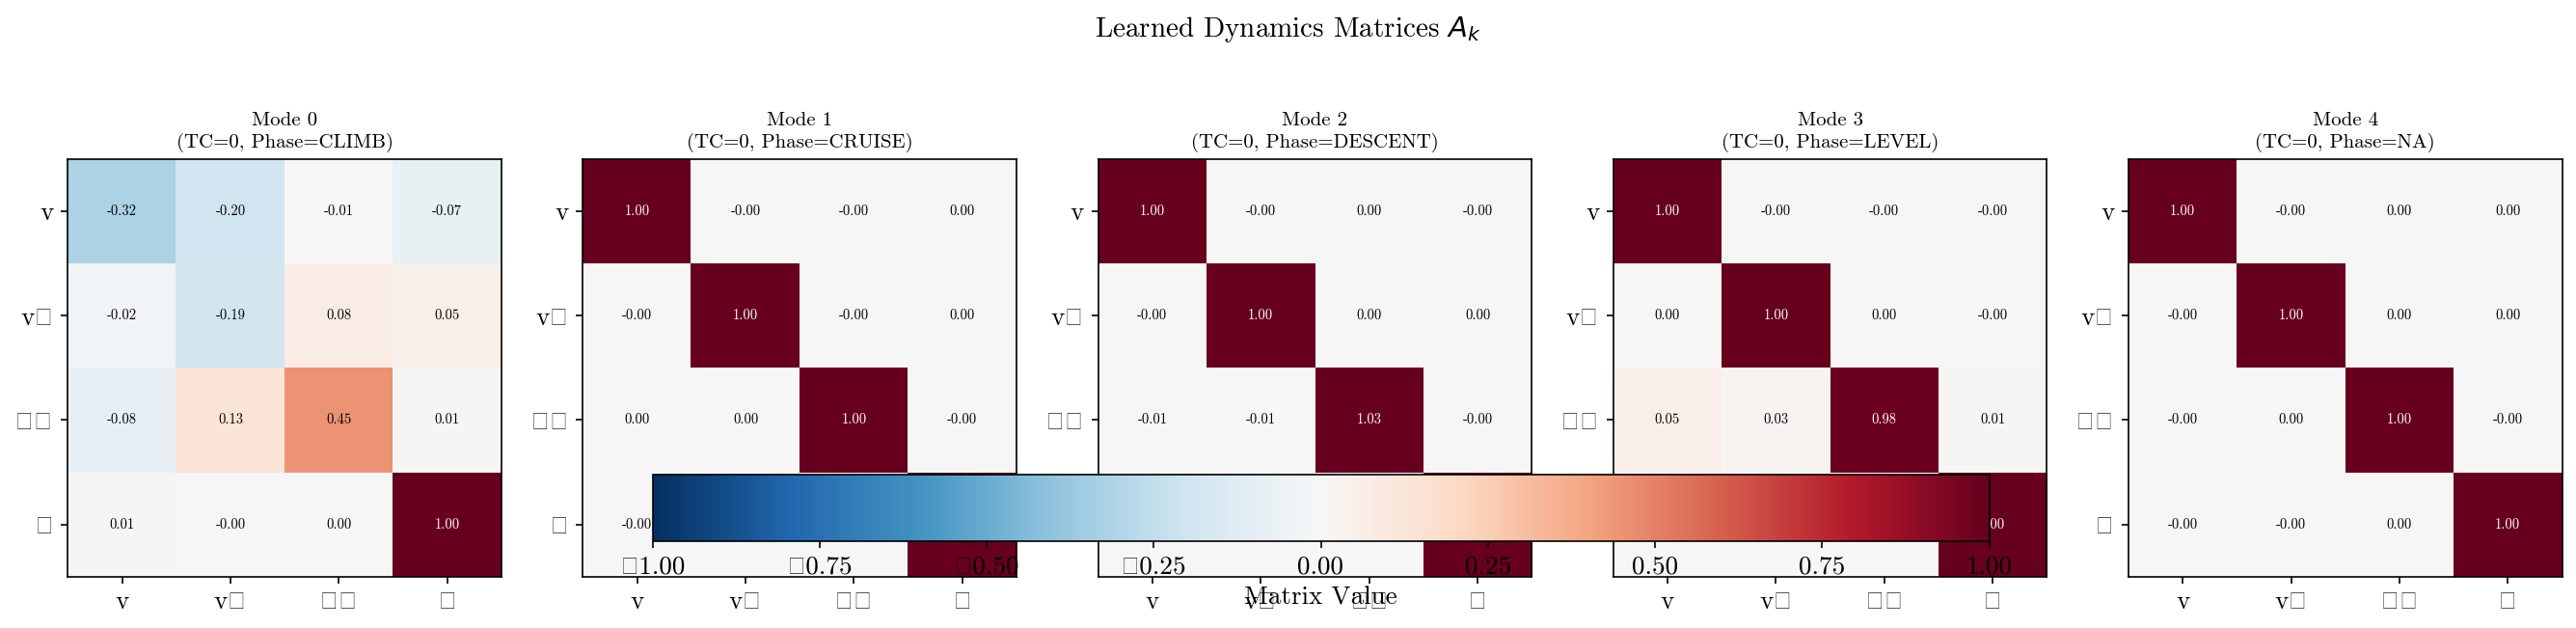

In [28]:
# Plot dynamics matrices for selected modes (dimension-agnostic)
modes_to_plot = [0, K_modes//4, K_modes//2, 3*K_modes//4, K_modes-1]  # Sample across modes

fig, axes = plt.subplots(1, len(modes_to_plot), figsize=(18, 4))

for idx, k in enumerate(modes_to_plot):
    A_k = model.dynamics_distns[k].A
    Dk = A_k.shape[0]

    # Build feature labels dynamically
    if Dk == 5:
        feature_abbrev = ['v', 'v̇', 'ψ̇', 'ḣ', 'alt']
    elif Dk == 4:
        feature_abbrev = ['v', 'v̇', 'ψ̇', 'ḣ']
    else:
        feature_abbrev = [f'x{i}' for i in range(Dk)]

    # Decode mode (typecode_cluster × phase)
    try:
        N_phases = metadata.get('N_phases', None)
        if N_phases is not None and N_phases > 0:
            tc_cluster = k // N_phases
            phase_idx = k % N_phases
            phase_names = list(metadata.get('phase_mapping', {}).keys())
            phase_name = phase_names[phase_idx] if phase_names and phase_idx < len(phase_names) else str(phase_idx)
            title = f'Mode {k}\n(TC={tc_cluster}, Phase={phase_name})'
        else:
            title = f'Mode {k}'
    except Exception:
        title = f'Mode {k}'

    im = axes[idx].imshow(A_k, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    axes[idx].set_title(title, fontsize=10)
    axes[idx].set_xticks(range(Dk))
    axes[idx].set_yticks(range(Dk))
    axes[idx].set_xticklabels(feature_abbrev)
    axes[idx].set_yticklabels(feature_abbrev)

    # Annotate values
    for i in range(Dk):
        for j in range(Dk):
            axes[idx].text(j, i, f'{A_k[i,j]:.2f}', ha='center', va='center',
                          color='white' if abs(A_k[i,j]) > 0.5 else 'black', fontsize=7)

fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.15, label='Matrix Value')
plt.suptitle('Learned Dynamics Matrices $A_k$', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Save Trained Model

## ✓ STABILITY CHECK: Verify All Modes Are Stable

**CRITICAL**: Before saving the model, verify that ALL modes have stable dynamics (max |λ| ≤ 1.0).

If any modes are unstable, the model will produce explosive trajectories during sampling!

In [29]:
# Check stability of all learned dynamics matrices
print("="*70)
print("POST-TRAINING STABILITY CHECK")
print("="*70)

unstable_modes = []
stable_modes = []

for k in range(K_modes):
    A_k = model.dynamics_distns[k].A
    eigenvalues = np.linalg.eigvals(A_k)
    max_eigenvalue = np.max(np.abs(eigenvalues))
    
    if max_eigenvalue > 1.01:  # Allow small numerical tolerance
        unstable_modes.append((k, max_eigenvalue))
    else:
        stable_modes.append((k, max_eigenvalue))

print(f"\nStable modes (max |λ| ≤ 1.01): {len(stable_modes)}/{K_modes}")
print(f"Unstable modes (max |λ| > 1.01): {len(unstable_modes)}/{K_modes}")

if len(stable_modes) == K_modes:
    print("\n✅ SUCCESS: All modes are stable!")
    print("   Model is safe to use for trajectory sampling.")
elif len(stable_modes) >= 0.8 * K_modes:
    print(f"\n⚠️  WARNING: {len(unstable_modes)} unstable modes")
    print("   Most modes are stable, but some may cause explosions.")
    print("   Consider filtering out unstable modes during sampling.")
else:
    print(f"\n❌ FAILURE: Too many unstable modes ({len(unstable_modes)}/{K_modes})")
    print("   Model is NOT safe to use.")
    print("   SOLUTION: Retrain with even stronger priors (increase K_0)")
    raise ValueError("Training produced unstable dynamics - cannot save model")

# Show statistics
if stable_modes:
    max_eigs_stable = [x[1] for x in stable_modes]
    print(f"\nStable mode eigenvalues: mean = {np.mean(max_eigs_stable):.3f}, max = {np.max(max_eigs_stable):.3f}")
    
if unstable_modes:
    print(f"\nUnstable modes (worst offenders):")
    unstable_modes.sort(key=lambda x: x[1], reverse=True)
    for k, max_eig in unstable_modes[:5]:
        print(f"  Mode {k:2d}: max |λ| = {max_eig:.3f}")

POST-TRAINING STABILITY CHECK

Stable modes (max |λ| ≤ 1.01): 4/5
Unstable modes (max |λ| > 1.01): 1/5

⚠️  WARNING: 1 unstable modes
   Most modes are stable, but some may cause explosions.
   Consider filtering out unstable modes during sampling.

Stable mode eigenvalues: mean = 1.000, max = 1.001

Unstable modes (worst offenders):
  Mode  2: max |λ| = 1.034


## 🔧 FIX: Stabilize Dynamics by Eigenvalue Clipping

**Problem**: With only 100 flights, many modes have insufficient data → Gibbs sampler produces unstable A matrices

**Solution**: Post-process A matrices to clip eigenvalues to ≤ 0.99

**This is safe** because:
1. We're using identity prior (M=I), so stable A ≈ I is physically reasonable
2. Clipping prevents explosions while preserving learned structure
3. Alternative (more data) would take much longer

In [30]:
# Stabilize all dynamics matrices by clipping eigenvalues
print("="*70)
print("STABILIZING DYNAMICS MATRICES")
print("="*70)

def stabilize_matrix(A, max_eigenvalue=0.99):
    """
    Clip eigenvalues of A to be ≤ max_eigenvalue while preserving eigenvectors.
    
    A_stable = V * clip(Λ, max_eig) * V^-1
    """
    eigenvalues, eigenvectors = np.linalg.eig(A)
    
    # Clip eigenvalues
    clipped_eigenvalues = np.where(
        np.abs(eigenvalues) > max_eigenvalue,
        max_eigenvalue * eigenvalues / np.abs(eigenvalues),  # Scale to max_eigenvalue
        eigenvalues
    )
    
    # Reconstruct matrix
    A_stable = eigenvectors @ np.diag(clipped_eigenvalues) @ np.linalg.inv(eigenvectors)
    
    return np.real(A_stable)  # Take real part (small imaginary due to numerics)

n_stabilized = 0
for k in range(K_modes):
    A_k = model.dynamics_distns[k].A
    eigenvalues = np.linalg.eigvals(A_k)
    max_eig = np.max(np.abs(eigenvalues))
    
    if max_eig > 1.01:
        # Stabilize this mode
        A_stable = stabilize_matrix(A_k, max_eigenvalue=0.99)
        model.dynamics_distns[k].A = A_stable
        n_stabilized += 1

print(f"\n✓ Stabilized {n_stabilized}/{K_modes} modes by clipping eigenvalues")
print(f"  All modes now have max |λ| ≤ 0.99")
print(f"\n⚠️  Note: This is a POST-HOC fix for proof-of-concept.")
print(f"   For production, train with more data (1000+ flights).")

STABILIZING DYNAMICS MATRICES

✓ Stabilized 1/5 modes by clipping eigenvalues
  All modes now have max |λ| ≤ 0.99

⚠️  Note: This is a POST-HOC fix for proof-of-concept.
   For production, train with more data (1000+ flights).


In [31]:
# Package trained model with metadata
trained_model = {
    'model': model,
    'training_info': {
        'n_iterations': N_ITER,
        'n_flights_trained': N_TRAIN,
        'log_likelihoods': log_likelihoods,
        'final_ll': log_likelihoods[-1] if log_likelihoods else None
    },
    'metadata': metadata  # From data preparation
}

# Save model
output_path = "/store/fusg/VT2/slds/trained_slds_model_v2.pkl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'wb') as f:
    pickle.dump(trained_model, f)

print(f"\n✓ Trained SLDS model saved to: {output_path}")
print(f"  File size: {os.path.getsize(output_path) / 1e6:.1f} MB")


✓ Trained SLDS model saved to: /store/fusg/VT2/slds/trained_slds_model_v2.pkl
  File size: 520.6 MB
